# ML-testbed 14 — a complete synthetic inference loop

Bring the pieces together: configure a machine, acquire partial diagnostic evidence, infer uncertain parameters, choose an additional synthetic measurement, update the posterior, predict trajectories and give an LM access to the numerical result. Save the configuration, evidence and decisions as one run.

This is the first complete teaching slice of the eventual framework. It is not a full simulation of Z or a facility experiment optimizer.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** Bayesian experimental design, expected information gain, sequential inference, posterior predictive checks, integrated evidence records

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. Freeze the experiment-design question
We infer charge and mass; resistance is fixed at .22 and gains/timing are assumed known. Begin with current summaries only. Candidate actions add one family of reconstructed summaries: speed, radius or thermal proxy. Costs are fictional teaching units. The objective is expected reduction in **joint charge–mass grid entropy per cost**.

The posterior is exact for this discrete grid and assumed likelihood. It is not exact inference for real physics. Acquisition uses the synthetic diagnostic-summary operator from lesson 08, not raw-instrument reconstructions. Closing the raw-to-inference path with calibrated reconstruction uncertainty is a future extension.

In [2]:
seed_all(1401)
true_theta=torch.tensor([[1.07,.83,.22,.6]])
# Only the acquisition function may see the synthetic world. Inference gets returned measurements.
with torch.no_grad(): synthetic_signal=summaries(true_theta)[0]
generator=torch.Generator().manual_seed(1402)
def acquire(indices,sigma=SUMMARY_SIGMA):
    idx=torch.tensor(indices); return synthetic_signal[idx]+torch.randn(len(indices),generator=generator)*sigma[idx]
observed=torch.full((12,),float('nan')); observed[:3]=acquire([0,1,2])
initial=grid_posterior(observed,channels=[0,1,2],n=41)
weights=initial['weights']; predictions=initial['predictions']; parameters=initial['theta']
print('Initial mean charge/mass:',initial['mean'][:2].tolist())
print('Initial 90% mass interval:',weighted_interval(parameters[:,1],weights).tolist())

Initial mean charge/mass: [1.0622190237045288, 1.0090460777282715]
Initial 90% mass interval: [0.6850000023841858, 1.3324999809265137]


## 2. Estimate the value of an additional diagnostic
Draw hypothetical truths from the current posterior, simulate possible measurements, and update the posterior for each. Average the entropy reduction. A large score means an instrument is expected to distinguish currently plausible parameter combinations, under the current model. It does not rank real hardware feasibility or safety.

[{'diagnostic': 'speed',
  'expected_gain_nats': 1.6324070692062378,
  'MC_standard_error': 0.05439824238419533,
  'cost': 1.0,
  'gain_per_cost': 1.6324070692062378},
 {'diagnostic': 'radius',
  'expected_gain_nats': 0.8056921362876892,
  'MC_standard_error': 0.06039123237133026,
  'cost': 1.2,
  'gain_per_cost': 0.6714101135730743},
 {'diagnostic': 'thermal_proxy',
  'expected_gain_nats': 0.07033130526542664,
  'MC_standard_error': 0.0007395389256998897,
  'cost': 0.8,
  'gain_per_cost': 0.0879141315817833}]

Selected synthetic acquisition: speed


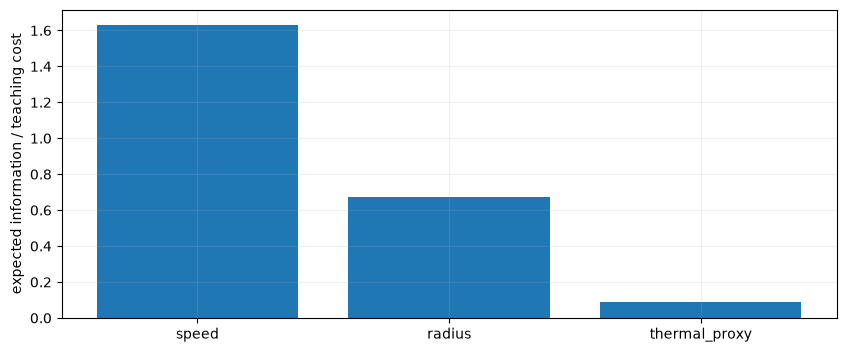

In [3]:
candidates={'speed':{'indices':[3,4,5],'cost':1.0},
            'radius':{'indices':[6,7,8],'cost':1.2},
            'thermal_proxy':{'indices':[9,10,11],'cost':.8}}
def expected_gain(prior,indices,seed,draws=48):
    gen=torch.Generator().manual_seed(seed); idx=torch.tensor(indices)
    choice=torch.multinomial(prior,draws,replacement=True,generator=gen)
    potential=predictions[choice][:,idx]+torch.randn(draws,len(idx),generator=gen)*SUMMARY_SIGMA[idx]
    residual=(potential[:,None,:]-predictions[None,:,idx])/SUMMARY_SIGMA[idx]
    posterior=torch.softmax(torch.log(prior.clamp_min(1e-30))[None]-.5*residual.square().sum(-1),dim=1)
    entropies=-(posterior*torch.log(posterior.clamp_min(1e-30))).sum(1)
    gains=entropy(prior)-entropies
    return float(gains.mean()),float(gains.std()/np.sqrt(draws))
design=[]
for j,(name,candidate) in enumerate(candidates.items()):
    gain,se=expected_gain(weights,candidate['indices'],1410+j)
    design.append({'diagnostic':name,'expected_gain_nats':gain,'MC_standard_error':se,'cost':candidate['cost'],'gain_per_cost':gain/candidate['cost']})
chosen=max(design,key=lambda row:row['gain_per_cost'])['diagnostic']
display(design); print('Selected synthetic acquisition:',chosen)
plt.bar([r['diagnostic'] for r in design],[r['gain_per_cost'] for r in design]); plt.ylabel('expected information / teaching cost'); plt.show()

### Visual lab — Compare information, uncertainty in the estimate, and cost

The left bars show expected information gain with one Monte Carlo standard error. The right bars divide the estimated gain by each candidate's fictional acquisition cost. Orange marks the selected candidate.

**Notice:** the selection is conditional on this posterior, noise model and utility. Monte Carlo error is only numerical sampling uncertainty; it does not include errors in the physical model.

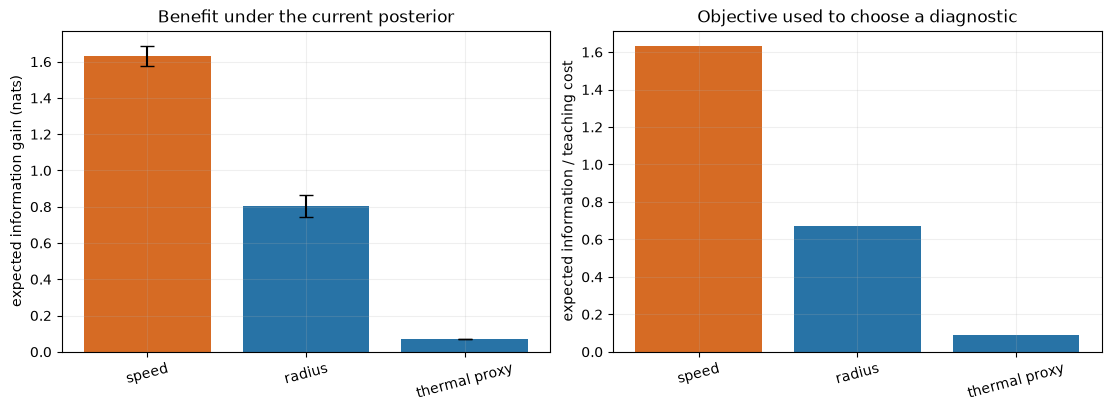

In [4]:
v_labels=[v_r['diagnostic'].replace('_',' ') for v_r in design]
v_colors=['#d66b24' if v_r['diagnostic']==chosen else '#2873a6' for v_r in design]
v_fig,v_axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
v_axes[0].bar(v_labels,[v_r['expected_gain_nats'] for v_r in design],yerr=[v_r['MC_standard_error'] for v_r in design],capsize=5,color=v_colors)
v_axes[0].set(ylabel='expected information gain (nats)',title='Benefit under the current posterior')
v_axes[1].bar(v_labels,[v_r['gain_per_cost'] for v_r in design],color=v_colors)
v_axes[1].set(ylabel='expected information / teaching cost',title='Objective used to choose a diagnostic')
for v_ax in v_axes: v_ax.tick_params(axis='x',labelrotation=15)
plt.show()

## 3. Acquire, update, and retain the actual outcome
Expected information gain is an average over possible outcomes. One realized observation can occasionally increase uncertainty. Preserve that result instead of forcing the observed gain to be positive.

Actual entropy change: 1.9769251346588135
Updated mass interval: [0.7724999785423279, 0.8600000143051147]


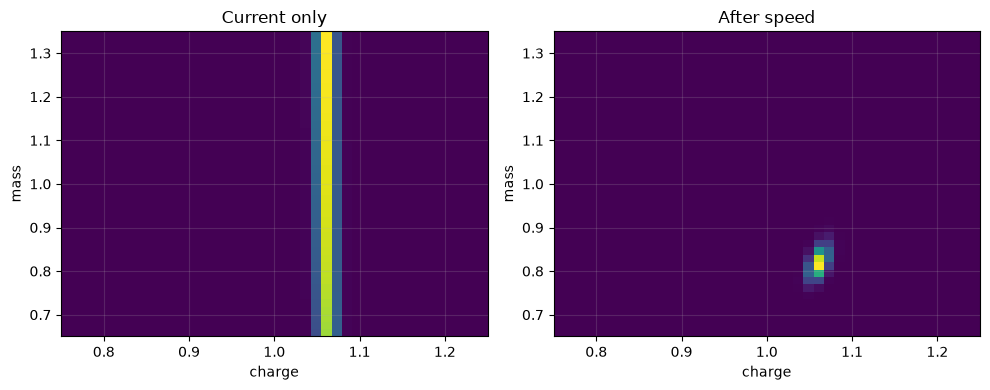

In [5]:
indices=candidates[chosen]['indices']; measurement=acquire(indices); observed[indices]=measurement
log_likelihood=-.5*(((predictions[:,indices]-measurement)/SUMMARY_SIGMA[indices])**2).sum(1)
updated=torch.softmax(torch.log(weights.clamp_min(1e-30))+log_likelihood,0)
mean_after=(updated[:,None]*parameters).sum(0)
print('Actual entropy change:',entropy(weights)-entropy(updated))
print('Updated mass interval:',weighted_interval(parameters[:,1],updated).tolist())
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,w,title in zip(axes,[weights,updated],['Current only','After '+chosen]):
    ax.imshow(w.reshape(41,41).T,origin='lower',extent=[.75,1.25,.65,1.35],aspect='auto')
    ax.set(title=title,xlabel='charge',ylabel='mass')
plt.tight_layout(); plt.show()

### Visual lab — Assimilate the newly acquired samples one at a time

The orange family contains three summary measurements. These panels sequentially add each actual acquired sample to the current-only posterior. All use the same discrete grid and a shared color scale; colors show posterior mass relative to the largest value across the panels.

**Notice:** an individual sample need not reduce uncertainty by the same amount as the next one. The entire sequence is conditional on the specified likelihood.

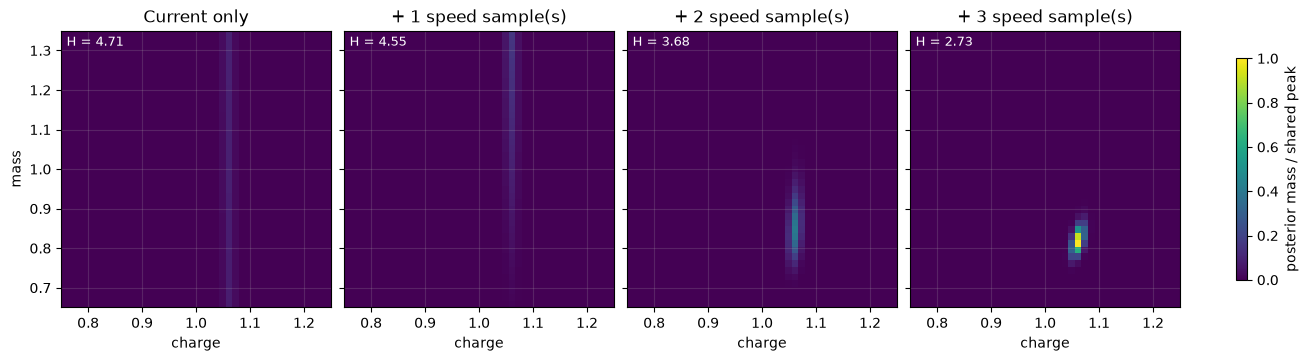

In [6]:
v_stage_weights=[weights]; v_logw=torch.log(weights.clamp_min(1e-30)).clone()
for v_j,v_index in enumerate(indices):
    v_logw=v_logw-.5*((predictions[:,v_index]-measurement[v_j])/SUMMARY_SIGMA[v_index]).square()
    v_stage_weights.append(torch.softmax(v_logw,0))
v_top=max(float(v_w.max()) for v_w in v_stage_weights)
v_fig,v_axes=plt.subplots(1,4,figsize=(13,3.5),sharex=True,sharey=True,layout='constrained')
for v_j,(v_ax,v_w) in enumerate(zip(v_axes,v_stage_weights)):
    v_im=v_ax.imshow(v_w.reshape(41,41).T.numpy()/v_top,origin='lower',extent=[.75,1.25,.65,1.35],aspect='auto',cmap='viridis',vmin=0,vmax=1)
    v_ax.set(title='Current only' if v_j==0 else f'+ {v_j} {chosen} sample(s)',xlabel='charge')
    v_ax.text(.02,.98,f'H = {entropy(v_w):.2f}',transform=v_ax.transAxes,va='top',color='white',fontsize=9)
v_axes[0].set_ylabel('mass'); v_fig.colorbar(v_im,ax=v_axes,label='posterior mass / shared peak',shrink=.8); plt.show()

## 4. Push parameter uncertainty through the world model
For this small problem, the numerical simulator is fast enough to propagate every grid point. The learned transition model from lesson 10 could replace it after its rollout error is incorporated. Sampling parameter uncertainty alone does not include uncertainty in equations, diagnostics, or surrogate approximation.

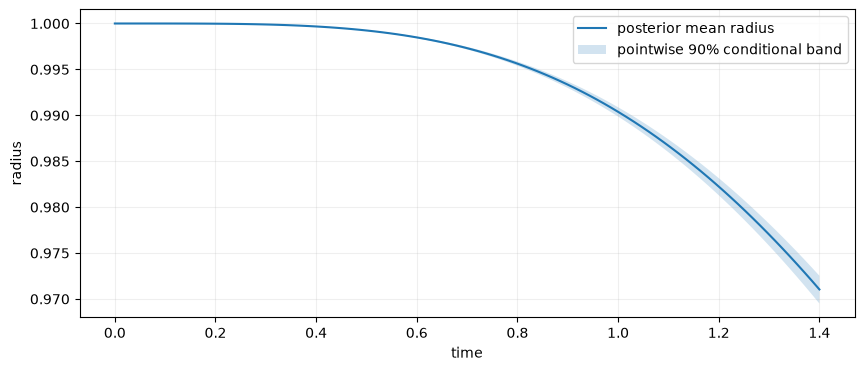

In [7]:
with torch.no_grad(): tt,paths=simulate(parameters)
mean_path=(paths*updated[:,None,None]).sum(0)
# Weighted pointwise quantiles, not a simultaneous trajectory band.
bands=torch.stack([weighted_interval(paths[:,j,2],updated) for j in range(paths.shape[1])])
plt.plot(tt,mean_path[:,2],label='posterior mean radius'); plt.fill_between(tt,bands[:,0],bands[:,1],alpha=.2,label='pointwise 90% conditional band')
plt.xlabel('time'); plt.ylabel('radius'); plt.legend(); plt.show()

## 5. Check predictions against a channel held back from fitting
Acquire the unselected candidate families after freezing the selection. These measurements are checks, not inputs to the posterior shown above. A posterior predictive check uses posterior predictive variance plus measurement variance. A large residual suggests some combination of wrong model, calibration, or reconstruction assumptions.

In [8]:
check_indices=[i for name,c in candidates.items() if name!=chosen for i in c['indices']]
check_values=acquire(check_indices)
pmean=(updated[:,None]*predictions).sum(0)
pvar=(updated[:,None]*(predictions-pmean).square()).sum(0)
check_z=(check_values-pmean[check_indices])/torch.sqrt(pvar[check_indices]+SUMMARY_SIGMA[check_indices]**2)
print('Held-back standardized residuals:',check_z.tolist())
print('Predictive check flagged:',bool((check_z.abs()>4).any()))
# Negative control: changed force coupling, same assumed inference operator.
with torch.no_grad(): wrong_signal=summaries(true_theta,replace(MachineConfig(),coupling=.2))[0]
wrong_z=(wrong_signal[check_indices]-pmean[check_indices])/torch.sqrt(pvar[check_indices]+SUMMARY_SIGMA[check_indices]**2)
print('Misspecified-world check residuals:',wrong_z.tolist())

Held-back standardized residuals: [-2.2701022624969482, -0.5726829171180725, 0.29139113426208496, -1.3357445001602173, 1.1361767053604126, -0.491401344537735]
Predictive check flagged: False
Misspecified-world check residuals: [-0.13371072709560394, -1.7216346263885498, -6.149710178375244, 0.024615364149212837, 0.12402602285146713, 0.1648416519165039]


### Visual lab — A held-back diagnostic can expose a wrong world model

Bars show standardized predictive residuals for the held-back channels. Blue uses the new noisy measurements from the matched simulator. Orange is the existing changed-coupling negative control, evaluated without added measurement noise. Both use the same posterior predictive denominator. These are diagnostic examples, not paired estimates of false-alarm rates.

**Notice:** a poor prediction flags inconsistency. It does not uniquely tell us whether the problem lies in the equations, calibration, or noise assumptions.

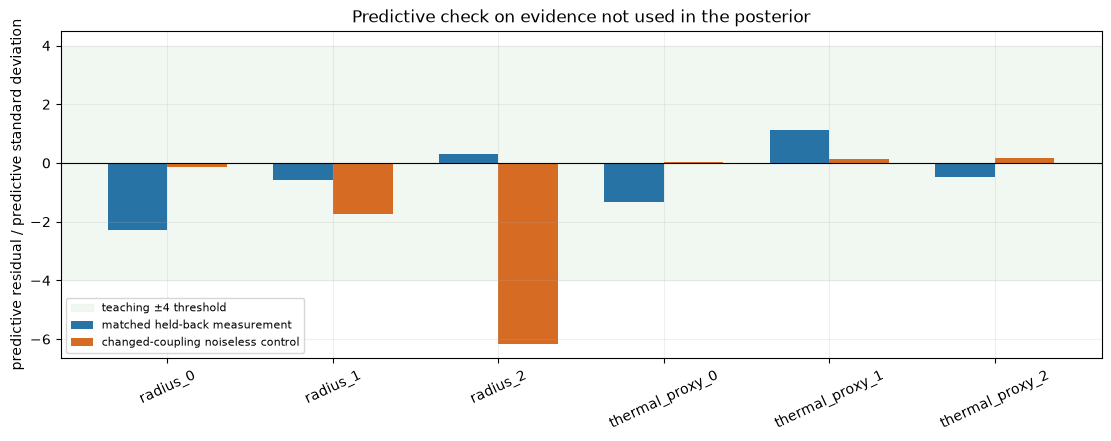

In [9]:
v_fig,v_ax=plt.subplots(figsize=(11,4.3),layout='constrained'); v_positions=np.arange(len(check_indices))
v_ax.bar(v_positions-.18,check_z.numpy(),width=.36,color='#2873a6',label='matched held-back measurement')
v_ax.bar(v_positions+.18,wrong_z.numpy(),width=.36,color='#d66b24',label='changed-coupling noiseless control')
v_ax.axhspan(-4,4,color='#ddefdf',alpha=.4,zorder=0,label='teaching ±4 threshold')
v_ax.axhline(0,color='black',lw=.8); v_ax.set(xticks=v_positions,xticklabels=[SUMMARY_NAMES[v_i] for v_i in check_indices],ylabel='predictive residual / predictive standard deviation',title='Predictive check on evidence not used in the posterior')
v_ax.tick_params(axis='x',labelrotation=25); v_ax.legend(fontsize=8); plt.show()

## 6. Evaluate uncertainty across independent synthetic shots
One attractive posterior plot proves little. Freeze the selected measurement family and test current-only versus augmented inference on 24 independent shots. This is a conditional evaluation for the chosen design; it does not evaluate the full adaptive selection policy across all worlds. Counts are small and public.

In [10]:
evaluation_theta=draw_parameters(24,1450); evaluation_theta[:,2]=.22
with torch.no_grad(): evaluation_signal=summaries(evaluation_theta)
evaluation_noise=torch.randn(evaluation_signal.shape,generator=torch.Generator().manual_seed(1451))*SUMMARY_SIGMA
evaluation_obs=evaluation_signal+evaluation_noise
study={}
for name,idx in [('current',[0,1,2]),('augmented',[0,1,2]+indices)]:
    covered=[]; widths=[]; errors=[]
    for obs_row,truth_row in zip(evaluation_obs,evaluation_theta):
        ll=-.5*(((predictions[:,idx]-obs_row[idx])/SUMMARY_SIGMA[idx])**2).sum(1)
        w=torch.softmax(ll,0); interval=weighted_interval(parameters[:,1],w)
        covered.append(float(interval[0]<=truth_row[1]<=interval[1])); widths.append(float(interval[1]-interval[0]))
        errors.append(float(((w*parameters[:,1]).sum()-truth_row[1]).abs()))
    study[name]={'mass_coverage90':float(np.mean(covered)),'mean_mass_interval_width':float(np.mean(widths)),'mass_MAE':float(np.mean(errors)),'shots':24}
display(study)

{'current': {'mass_coverage90': 1.0,
  'mean_mass_interval_width': 0.6416667153437933,
  'mass_MAE': 0.15424518783887228,
  'shots': 24},
 'augmented': {'mass_coverage90': 0.9166666666666666,
  'mean_mass_interval_width': 0.14802083124717078,
  'mass_MAE': 0.028807227810223896,
  'shots': 24}}

## 7. Hand a complete summary record to the LM runtime
The LM does not receive simulator parameters or trajectories. It chooses a tool from metadata; the numerical tool calculates an estimate and records its assumptions. To satisfy the runtime's current “motion available” contract, acquire both speed and radius summaries here. This is a **separate final request with more information** than the design comparison above.

In [11]:
from ml_testbed.language import train_lm, constrained_call
from ml_testbed.runtime import run_agent
from ml_testbed.language import expected_tool
final_observed=observed.clone()
for family in ([3,4,5],[6,7,8]):
    missing=[i for i in family if not torch.isfinite(final_observed[i])]
    if missing: final_observed[missing]=acquire(missing)
final_observed[9:]=float('nan')
public_record={'case':{'question':'mass','current':True,'motion':True,'clock':True},'summaries':final_observed,'shot_id':'capstone-public'}
seed_all(12); lm,_=train_lm()
agent_result=run_agent(lambda case:constrained_call(lm,case),public_record,max_calls=2)
rule_result=run_agent(lambda case:{'tool':expected_tool(case)},public_record,max_calls=2)
print('LM episode:'); display(agent_result)
print('Conventional episode:'); display(rule_result)

LM episode:


{'final': {'status': 'conditional_estimate',
  'parameter': 'mass',
  'mean': 0.8201441764831543,
  'interval90': [0.7666666507720947, 0.8600000143051147],
  'max_residual_sigma': 1.7304271459579468,
  'evidence': ['obs-8829f38bd72f2bd4'],
  'assumptions': ['dimensionless reduced model',
   'resistance fixed at .22',
   'uniform bounded prior',
   'known gains and aligned clocks',
   'Gaussian reconstructed-summary likelihood']},
 'trace': [{'call': {'tool': 'infer'},
   'result': {'status': 'conditional_estimate',
    'parameter': 'mass',
    'mean': 0.8201441764831543,
    'interval90': [0.7666666507720947, 0.8600000143051147],
    'max_residual_sigma': 1.7304271459579468,
    'evidence': ['obs-8829f38bd72f2bd4'],
    'assumptions': ['dimensionless reduced model',
     'resistance fixed at .22',
     'uniform bounded prior',
     'known gains and aligned clocks',
     'Gaussian reconstructed-summary likelihood']}}],
 'calls': 1,
 'budget': 2}

Conventional episode:


{'final': {'status': 'conditional_estimate',
  'parameter': 'mass',
  'mean': 0.8201441764831543,
  'interval90': [0.7666666507720947, 0.8600000143051147],
  'max_residual_sigma': 1.7304271459579468,
  'evidence': ['obs-8829f38bd72f2bd4'],
  'assumptions': ['dimensionless reduced model',
   'resistance fixed at .22',
   'uniform bounded prior',
   'known gains and aligned clocks',
   'Gaussian reconstructed-summary likelihood']},
 'trace': [{'call': {'tool': 'infer'},
   'result': {'status': 'conditional_estimate',
    'parameter': 'mass',
    'mean': 0.8201441764831543,
    'interval90': [0.7666666507720947, 0.8600000143051147],
    'max_residual_sigma': 1.7304271459579468,
    'evidence': ['obs-8829f38bd72f2bd4'],
    'assumptions': ['dimensionless reduced model',
     'resistance fixed at .22',
     'uniform bounded prior',
     'known gains and aligned clocks',
     'Gaussian reconstructed-summary likelihood']}}],
 'calls': 1,
 'budget': 2}

### Visual lab — Follow the full inference cycle

This map marks the stages completed in the capstone. The current-only posterior chooses a synthetic measurement; the new observation updates inference; held-back diagnostics check predictions. The final LM request uses a separately completed current-and-motion record, as described above.

**Notice:** a measurement request must produce new evidence before inference can use it. A language-model statement is not itself a new physical observation.

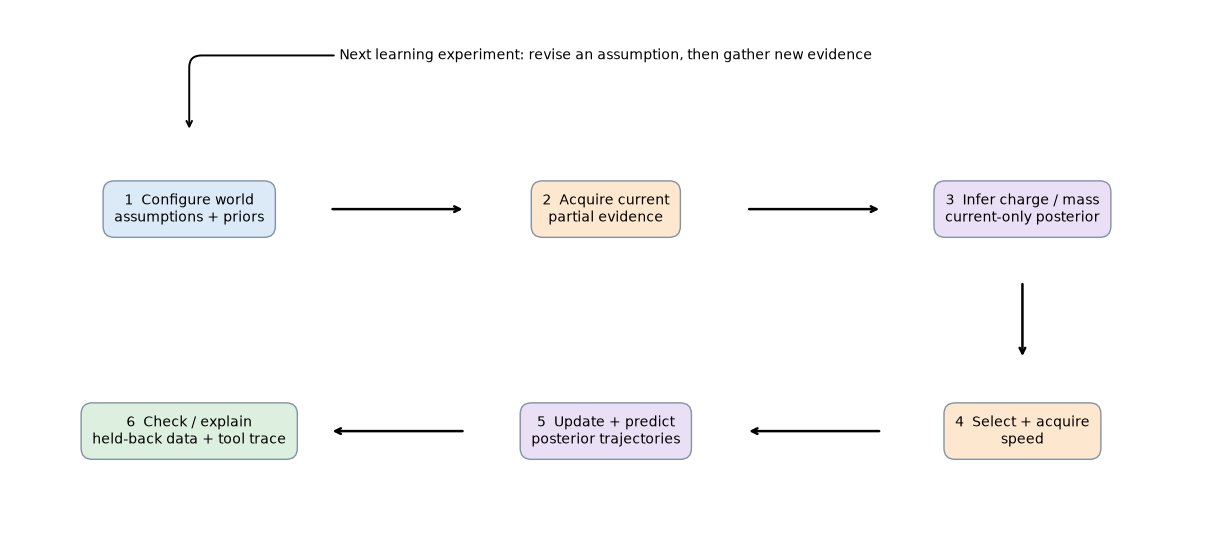

In [12]:
v_fig,v_ax=plt.subplots(figsize=(12,5.3),layout='constrained'); v_ax.axis('off')
v_nodes=[(0,2,'1  Configure world\nassumptions + priors','#dceaf7'),(4.3,2,'2  Acquire current\npartial evidence','#fde7ce'),(8.6,2,'3  Infer charge / mass\ncurrent-only posterior','#eae0f5'),
         (8.6,0,'4  Select + acquire\n'+chosen,'#fde7ce'),(4.3,0,'5  Update + predict\nposterior trajectories','#eae0f5'),(0,0,'6  Check / explain\nheld-back data + tool trace','#ddefdf')]
for v_x,v_y,v_label,v_color in v_nodes:v_ax.text(v_x,v_y,v_label,ha='center',va='center',fontsize=10,bbox=dict(boxstyle='round,pad=.8',fc=v_color,ec='#8293a2'))
for v_a,v_b in [((1.45,2),(2.85,2)),((5.75,2),(7.15,2)),((8.6,1.35),(8.6,.65)),((7.15,0),(5.75,0)),((2.85,0),(1.45,0))]:
    v_ax.annotate('',xy=v_b,xytext=v_a,arrowprops=dict(arrowstyle='->',lw=1.8))
v_ax.annotate('Next learning experiment: revise an assumption, then gather new evidence',xy=(0,2.7),xytext=(4.3,3.35),ha='center',fontsize=10,
              arrowprops=dict(arrowstyle='->',connectionstyle='angle,angleA=0,angleB=90,rad=12',lw=1.4))
v_ax.set(xlim=(-1.85,10.45),ylim=(-.9,3.8)); plt.show()

## 8. Save the experiment as a reproducible application record
The record contains assumed machine configuration, acquisition design, posterior summaries, checks, evaluation and agent trace. This is the contract Factor can consume through an adapter. Existing Factor APIs are left unchanged; `ml_testbed.runtime` is a standalone teaching interface.

In [13]:
metrics={'selected_diagnostic':chosen,'design_scores':design,'actual_entropy_reduction':entropy(weights)-entropy(updated),
         'posterior_mean':mean_after.tolist(),'predictive_check_z':check_z.tolist(),'mismatch_check_z':wrong_z.tolist(),
         'study':study,'LM_result':agent_result,'rule_result':rule_result}
config={'machine':asdict(MachineConfig()),'diagnostics':asdict(DiagnosticConfig()),
        'inference':{'parameters':['charge','mass'],'resistance_fixed':.22,'grid':41,'likelihood':'Gaussian reconstructed summaries'},
        'design':{'objective':'joint entropy reduction per synthetic cost','candidates':candidates,'MC_draws':48}}
run=save_run(ROOT,'14',metrics,config)
public_json={**public_record,'summaries':[float(v) if torch.isfinite(v) else None for v in final_observed]}
(run/'public_observations.json').write_text(json.dumps(public_json,indent=2,allow_nan=False))
(run/'experiment_config.json').write_text(json.dumps(config,indent=2))
print('Complete experiment record:',run)

Complete experiment record: /Users/operator/Desktop/Factor/runs/world-model/14-46f5a5298f


## What comes next in the framework
The layers are now explicit: configuration → evolving state → diagnostic response → reconstruction → posterior → decision → evidence. Each can be replaced independently.

Next substantial increments are a calibrated raw-signal likelihood, a circuit with time-dependent inputs, spatial material dynamics, uncertainty over model families, a learned observation/state-space model, natural-language tool-use training, and a Factor provider adapter. Higher-fidelity Z work would need physical units, validated constitutive laws, facility documentation, diagnostic calibration and independent real-data validation. This course establishes the software and learning patterns, not that validation.

## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Re-run design under a broad current-gain prior. Does another diagnostic become more valuable?
2. Evaluate the entire adaptive selection policy across new shots, including acquisition cost and failed predictive checks.
3. Connect the learned rollout surrogate while adding measured surrogate error to predictive uncertainty.